In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

In [3]:
import equinox as eqx
import esm  # pip install fair-esm==2.0.0
import esm2quinox
import jax.random as jrandom
import optax  # pip install optax
from dataset.dataset import initialize_datasets, Dataset_PEPBI
from functions.model import AFF_PREDICTOR,stripped_PREDICTOR, fine_tune_PREDICTOR
from functions.training import train_model, eval_step, train_model_validation, train_model_validation_combined, train_model_fine_tuning
import jax.numpy as jnp
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import jax.random as jr
import jax
import pandas as pd
from torch.utils.data import DataLoader, RandomSampler, random_split
import jax.tree_util as jtu
from functions import plots

In [4]:
base_path = '/home/kunzj'
#base_path = '/home/jkunz/master_uni_hd/internship_amsterdam'

pepbi dataset

In [ ]:
# data_train = Dataset_PEPBI(
#     columns=["Prot_Seq", "Pept_Seq", "Energy"],
#     data_path=f"{base_path}/BindCraft_uva_internship/data/pepbi/min_max_scaled/train_data_pepbi.csv",
#     transform=esm2quinox.tokenise
# )
# train_loader = DataLoader(data_train,batch_size=20)
# sns.kdeplot(data_train.aff_Vals)val_losses = [x.item() for x in val_losses]

# data_test = Dataset_PEPBI(
#     columns=["Prot_Seq", "Pept_Seq", "Energy"],
#     data_path=f"{base_path}/BindCraft_uva_internship/data/pepbi/min_max_scaled/test_data_pepbi.csv",
#     transform=esm2quinox.tokenise
# )
# test_loader = DataLoader(data_test,batch_size=1)
# test_key_init = jrandom.PRNGKey(1)

mmpbsa dataset - cosine similarity

In [6]:
data_mmpbsa_all = Dataset_PEPBI(
    columns=["seq_prot", "seq_pept", "final_score"],
    data_path=f"{base_path}/BindCraft_uva_internship/data/mmpbsa/finished_data_cosine_sim.csv",
    transform=esm2quinox.tokenise
)
data_mmpbsa_train = Dataset_PEPBI(
    columns=["seq_prot", "seq_pept", "final_score"],
    data_path=f"{base_path}/BindCraft_uva_internship/data/mmpbsa/split/finished_data_cosine_sim_train.csv",
    transform=esm2quinox.tokenise
)
data_mmpbsa_validation = Dataset_PEPBI(
    columns=["seq_prot", "seq_pept", "final_score"],
    data_path=f"{base_path}/BindCraft_uva_internship/data/mmpbsa/split/finished_data_cosine_sim_validation.csv",
    transform=esm2quinox.tokenise
)

data_mmpbsa_train_three_split= Dataset_PEPBI(
    columns=["seq_prot", "seq_pept", "final_score"],
    data_path=f"{base_path}/BindCraft_uva_internship/data/mmpbsa/three_way_split/finished_data_cosine_sim_train.csv",
    transform=esm2quinox.tokenise
)
data_mmpbsa_validation_three_split= Dataset_PEPBI(
    columns=["seq_prot", "seq_pept", "final_score"],
    data_path=f"{base_path}/BindCraft_uva_internship/data/mmpbsa/three_way_split/finished_data_cosine_sim_validation.csv",
    transform=esm2quinox.tokenise
)
data_mmpbsa_test_three_split= Dataset_PEPBI(
    columns=["seq_prot", "seq_pept", "final_score"],
    data_path=f"{base_path}/BindCraft_uva_internship/data/mmpbsa/three_way_split/finished_data_cosine_sim_test.csv",
    transform=esm2quinox.tokenise
)


mmpbsa_all_data_loader = DataLoader(data_mmpbsa_all,batch_size=1)
mmpbsa_train_data_loader = DataLoader(data_mmpbsa_train,batch_size=3)
mmpbsa_validation_data_loader = DataLoader(data_mmpbsa_validation,batch_size=1)


mmpbsa_train_data_loader_three_split = DataLoader(data_mmpbsa_train_three_split,batch_size=3)
mmpbsa_validation_data_loader_three_split = DataLoader(data_mmpbsa_validation_three_split,batch_size=1)
mmpbsa_test_data_loader_three_split = DataLoader(data_mmpbsa_test_three_split,batch_size=1)

In [ ]:
sns.kdeplot(data_mmpbsa_validation.aff_Vals)

In [ ]:
sns.histplot(data_mmpbsa_train.aff_Vals)

In [ ]:
sns.histplot(data_mmpbsa_validation.aff_Vals)

<Axes: ylabel='Count'>

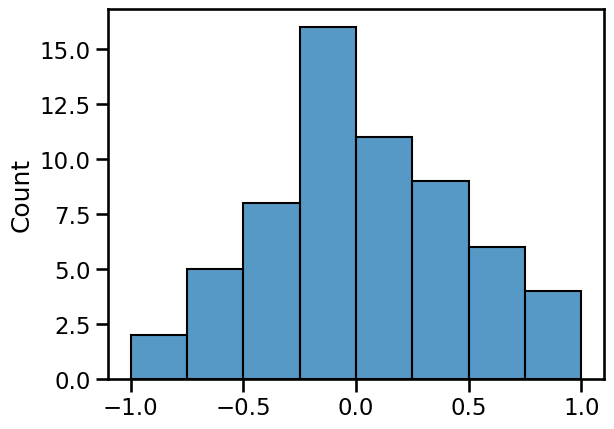

In [44]:
sns.histplot(data_mmpbsa_train_three_split.aff_Vals)

<Axes: ylabel='Count'>

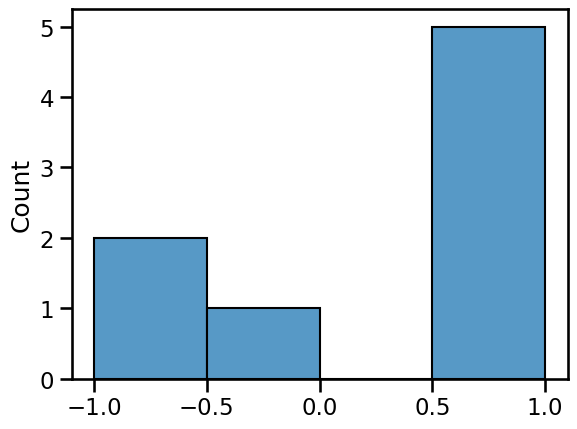

In [45]:
sns.histplot(data_mmpbsa_validation_three_split.aff_Vals)

<Axes: ylabel='Count'>

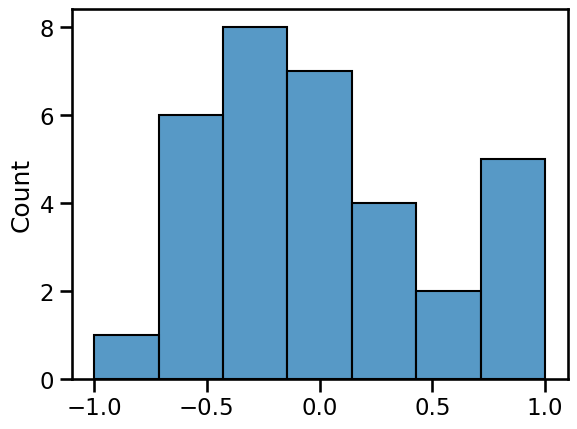

In [46]:
sns.histplot(data_mmpbsa_test_three_split.aff_Vals)

ppi affinity dataset - cosine similarity


In [7]:
data_train = Dataset_PEPBI(
    columns=["Prot_Seq", "Pept_Seq", "Energy"],
    data_path=f"{base_path}/BindCraft_uva_internship/data/ppi_affinity_dataset/cosine_sim_scaled/train.csv",
    transform=esm2quinox.tokenise,
)
train_loader = DataLoader(data_train, batch_size=20)



data_validation = Dataset_PEPBI(
    columns=["Prot_Seq", "Pept_Seq", "Energy"],
    data_path=f"{base_path}/BindCraft_uva_internship/data/ppi_affinity_dataset/cosine_sim_scaled/validation.csv",
    transform=esm2quinox.tokenise,
)
validation_loader = DataLoader(data_validation, batch_size=1)

data_test = Dataset_PEPBI(
    columns=["Prot_Seq", "Pept_Seq", "Energy"],
    data_path=f"{base_path}/BindCraft_uva_internship/data/ppi_affinity_dataset/cosine_sim_scaled/test.csv",
    transform=esm2quinox.tokenise,
)
test_loader = DataLoader(data_test, batch_size=1)

test_key_init = jrandom.PRNGKey(1)

W1126 10:44:00.278219  115298 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W1126 10:44:00.280442  115299 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W1126 10:44:00.285187  115024 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W1126 10:44:00.286648  115024 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.


<Axes: ylabel='Count'>

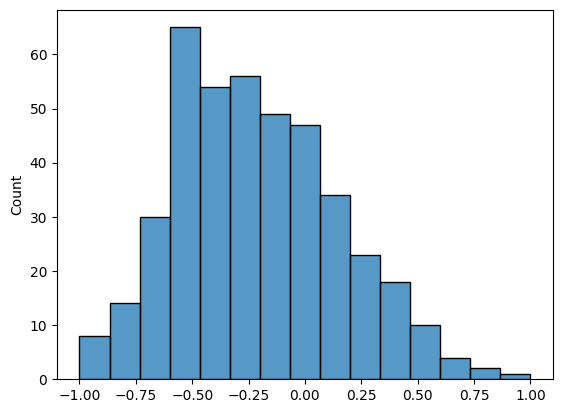

In [9]:
sns.histplot(data_train.aff_Vals)

<Axes: ylabel='Count'>

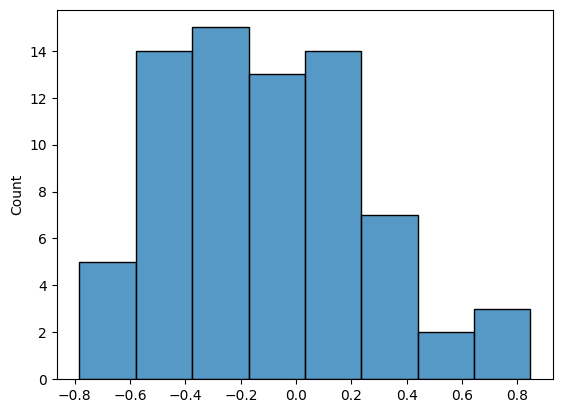

In [10]:
sns.histplot(data_validation.aff_Vals)

model initilialization

In [16]:
# generating keys
model_key, call_key = jr.split(jrandom.PRNGKey(0), 2)

# initializing models
torch_model, _ = esm.pretrained.esm2_t30_150M_UR50D()
model_esm2 = esm2quinox.from_torch(torch_model)
model_aff, model_state = eqx.nn.make_with_state(stripped_PREDICTOR)(
    model=model_esm2, key=model_key
)

# initializing optimizer
optim = optax.adam(learning_rate=0.001)
opt_state = optim.init(eqx.filter(model_aff, eqx.is_inexact_array))


In [15]:
a=np.zeros((1, 162, 640))
a.squeeze().shape

(162, 640)

In [17]:
target_str =['QPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELALDPVPQDASTKKLSECLKRIGDELDSNMELQRMIAAVDTDSPREVFFRVAADMFSDGNFNWGRVVALFYFASKLVLKALCTKVPELIRTIMGWTLDFLRERLLGWIQDQGGWDGLLSYFG']
x_prot = esm2quinox.tokenise(target_str)
test_key = model_key[0]

inference_model = eqx.nn.inference_mode(model_aff)
inference_model = eqx.Partial(inference_model, state=model_state)

In [18]:
inference_model(x_prot,x_prot,key=test_key)

ValueError: `eqx.nn.Embedding()(x)` should be called with a scalar index `x`. Use `jax.vmap` if you would like to index with multiple values.

train model

train model with validation

In [ ]:
best_model, model_state, train_losses, val_losses = train_model_validation(
    training_DataLoader=train_loader,
    validation_Dataloader=validation_loader,
    max_epochs=3,
    model_aff=model_aff,
    model_state=model_state,
    opt_state=opt_state,
    optim=optim,
    key=call_key,
)

additional training with mmpbsa data

In [ ]:
best_model, model_state, train_losses, val_losses = train_model_validation(
    training_DataLoader=mmpbsa_train_data_loader_three_split,
    validation_Dataloader=mmpbsa_validation_data_loader_three_split,
    max_epochs=100,
    model_aff=model_aff,
    model_state=model_state,
    opt_state=opt_state,
    optim=optim,
    key=call_key,
)

test - ppbi data

In [27]:
test_key_init = jrandom.PRNGKey(1)
inference_model = eqx.nn.inference_mode(best_model)
inference_model = eqx.Partial(inference_model, state=model_state)

test_loss_list = []
pred_y_list = []
y_val_list = []

for entry, (x_prot, x_pept, y_val) in enumerate(test_loader):
    x_prot, x_pept, y_val = jnp.array(x_prot), jnp.array(x_pept), jnp.array(y_val)
    test_key = jr.split(test_key_init, x_pept.shape[0])
    test_loss, pred_y = eval_step(inference_model, x_prot, x_pept, y_val, test_key)
    test_loss_list.append(test_loss.item())
    pred_y_list.append(pred_y.item())
    y_val_list.append(y_val.item())
    print(
        f"[Entry {entry + 1}] , Test Loss: {test_loss:.3f}, Predicted Y: {pred_y.item():.3f}, , True Y: {y_val.item():.3f}"
    )


[Entry 1] , Test Loss: 0.047, Predicted Y: -0.099, , True Y: -0.315
[Entry 2] , Test Loss: 0.042, Predicted Y: -0.435, , True Y: -0.641
[Entry 3] , Test Loss: 0.142, Predicted Y: -0.075, , True Y: -0.452
[Entry 4] , Test Loss: 0.028, Predicted Y: -0.387, , True Y: -0.220
[Entry 5] , Test Loss: 0.149, Predicted Y: 0.178, , True Y: -0.207
[Entry 6] , Test Loss: 0.073, Predicted Y: -0.524, , True Y: -0.254
[Entry 7] , Test Loss: 0.033, Predicted Y: 0.055, , True Y: 0.237
[Entry 8] , Test Loss: 0.110, Predicted Y: 0.251, , True Y: -0.080
[Entry 9] , Test Loss: 0.135, Predicted Y: -0.218, , True Y: -0.585
[Entry 10] , Test Loss: 0.103, Predicted Y: 0.304, , True Y: -0.018
[Entry 11] , Test Loss: 0.234, Predicted Y: -0.595, , True Y: -0.111
[Entry 12] , Test Loss: 0.020, Predicted Y: -0.296, , True Y: -0.438
[Entry 13] , Test Loss: 0.951, Predicted Y: 0.466, , True Y: -0.510
[Entry 14] , Test Loss: 0.028, Predicted Y: 0.345, , True Y: 0.178
[Entry 15] , Test Loss: 0.545, Predicted Y: -0.505,

test - mmpbsa data

In [24]:
test_key_init = jrandom.PRNGKey(1)
inference_model = eqx.nn.inference_mode(best_model)
inference_model = eqx.Partial(inference_model, state=model_state)

test_loss_list = []
pred_y_list = []
y_val_list = []

for entry, (x_prot, x_pept, y_val) in enumerate(mmpbsa_all_data_loader):
    x_prot, x_pept, y_val = jnp.array(x_prot), jnp.array(x_pept), jnp.array(y_val)
    test_key = jr.split(test_key_init, x_pept.shape[0])
    test_loss, pred_y = eval_step(inference_model, x_prot, x_pept, y_val, test_key)
    test_loss_list.append(test_loss.item())
    pred_y_list.append(pred_y.item())
    y_val_list.append(y_val.item())
    print(
        f"[Entry {entry + 1}] , Test Loss: {test_loss:.3f}, Predicted Y: {pred_y.item():.3f}, , True Y: {y_val.item():.3f}"
    )


[Entry 1] , Test Loss: 0.045, Predicted Y: -0.037, , True Y: -0.250
[Entry 2] , Test Loss: 0.006, Predicted Y: -0.209, , True Y: -0.287
[Entry 3] , Test Loss: 0.000, Predicted Y: -0.141, , True Y: -0.140
[Entry 4] , Test Loss: 0.000, Predicted Y: 0.091, , True Y: 0.110
[Entry 5] , Test Loss: 0.020, Predicted Y: 0.209, , True Y: 0.069
[Entry 6] , Test Loss: 0.015, Predicted Y: 0.440, , True Y: 0.318
[Entry 7] , Test Loss: 0.028, Predicted Y: 0.392, , True Y: 0.558
[Entry 8] , Test Loss: 0.000, Predicted Y: -0.021, , True Y: -0.020
[Entry 9] , Test Loss: 0.173, Predicted Y: 0.494, , True Y: 0.910
[Entry 10] , Test Loss: 0.067, Predicted Y: 0.187, , True Y: 0.446
[Entry 11] , Test Loss: 0.035, Predicted Y: 0.278, , True Y: 0.092
[Entry 12] , Test Loss: 0.065, Predicted Y: 0.045, , True Y: -0.209
[Entry 13] , Test Loss: 0.005, Predicted Y: 0.041, , True Y: -0.028
[Entry 14] , Test Loss: 0.016, Predicted Y: 0.002, , True Y: -0.126
[Entry 15] , Test Loss: 0.220, Predicted Y: 0.245, , True Y:

In [30]:
test_key_init = jrandom.PRNGKey(1)
inference_model = eqx.nn.inference_mode(best_model)
inference_model = eqx.Partial(inference_model, state=model_state)

test_loss_list = []
pred_y_list = []
y_val_list = []

for entry, (x_prot, x_pept, y_val) in enumerate(mmpbsa_test_data_loader_three_split):
    x_prot, x_pept, y_val = jnp.array(x_prot), jnp.array(x_pept), jnp.array(y_val)
    test_key = jr.split(test_key_init, x_pept.shape[0])
    test_loss, pred_y = eval_step(inference_model, x_prot, x_pept, y_val, test_key)
    test_loss_list.append(test_loss.item())
    pred_y_list.append(pred_y.item())
    y_val_list.append(y_val.item())
    print(
        f"[Entry {entry + 1}] , Test Loss: {test_loss:.3f}, Predicted Y: {pred_y.item():.3f}, , True Y: {y_val.item():.3f}"
    )


[Entry 1] , Test Loss: 0.207, Predicted Y: -0.209, , True Y: -0.663
[Entry 2] , Test Loss: 0.085, Predicted Y: -0.141, , True Y: -0.433
[Entry 3] , Test Loss: 0.549, Predicted Y: 0.245, , True Y: -0.496
[Entry 4] , Test Loss: 0.062, Predicted Y: 0.291, , True Y: 0.042
[Entry 5] , Test Loss: 0.910, Predicted Y: 0.046, , True Y: 1.000
[Entry 6] , Test Loss: 0.001, Predicted Y: 0.291, , True Y: 0.266
[Entry 7] , Test Loss: 0.029, Predicted Y: 0.382, , True Y: 0.212
[Entry 8] , Test Loss: 0.247, Predicted Y: 0.725, , True Y: 0.228
[Entry 9] , Test Loss: 0.113, Predicted Y: 0.213, , True Y: -0.122
[Entry 10] , Test Loss: 0.007, Predicted Y: -0.156, , True Y: -0.073
[Entry 11] , Test Loss: 0.148, Predicted Y: 0.228, , True Y: -0.157
[Entry 12] , Test Loss: 0.058, Predicted Y: 0.437, , True Y: 0.678
[Entry 13] , Test Loss: 0.128, Predicted Y: 0.133, , True Y: -0.225
[Entry 14] , Test Loss: 0.158, Predicted Y: 0.159, , True Y: -0.239
[Entry 15] , Test Loss: 0.008, Predicted Y: 0.467, , True Y:

test intermediate model

In [14]:
test_key_init = jrandom.PRNGKey(1)
inference_model = eqx.nn.inference_mode(best_model_first)
inference_model = eqx.Partial(inference_model, state=model_state_first)

test_loss_list = []
pred_y_list = []
y_val_list = []

for entry, (x_prot, x_pept, y_val) in enumerate(mmpbsa_all_data_loader):
    x_prot, x_pept, y_val = jnp.array(x_prot), jnp.array(x_pept), jnp.array(y_val)
    test_key = jr.split(test_key_init, x_pept.shape[0])
    test_loss, pred_y = eval_step(inference_model, x_prot, x_pept, y_val, test_key)
    test_loss_list.append(test_loss.item())
    pred_y_list.append(pred_y.item())
    y_val_list.append(y_val.item())
    print(
        f"[Entry {entry + 1}] , Test Loss: {test_loss:.3f}, Predicted Y: {pred_y.item():.3f}, , True Y: {y_val.item():.3f}"
    )

[Entry 1] , Test Loss: 0.035, Predicted Y: -0.062, , True Y: -0.250
[Entry 2] , Test Loss: 0.021, Predicted Y: -0.141, , True Y: -0.287
[Entry 3] , Test Loss: 0.005, Predicted Y: -0.207, , True Y: -0.140
[Entry 4] , Test Loss: 0.015, Predicted Y: -0.013, , True Y: 0.110
[Entry 5] , Test Loss: 0.003, Predicted Y: 0.017, , True Y: 0.069
[Entry 6] , Test Loss: 0.096, Predicted Y: 0.008, , True Y: 0.318
[Entry 7] , Test Loss: 0.334, Predicted Y: -0.020, , True Y: 0.558
[Entry 8] , Test Loss: 0.000, Predicted Y: -0.007, , True Y: -0.020
[Entry 9] , Test Loss: 0.790, Predicted Y: 0.022, , True Y: 0.910
[Entry 10] , Test Loss: 0.138, Predicted Y: 0.075, , True Y: 0.446
[Entry 11] , Test Loss: 0.037, Predicted Y: -0.101, , True Y: 0.092
[Entry 12] , Test Loss: 0.010, Predicted Y: -0.112, , True Y: -0.209
[Entry 13] , Test Loss: 0.018, Predicted Y: -0.160, , True Y: -0.028
[Entry 14] , Test Loss: 0.006, Predicted Y: -0.050, , True Y: -0.126
[Entry 15] , Test Loss: 0.153, Predicted Y: 0.167, , T

In [33]:
test_key_init = jrandom.PRNGKey(1)
inference_model = eqx.nn.inference_mode(best_model_first)
inference_model = eqx.Partial(inference_model, state=model_state_first)

test_loss_list = []
pred_y_list = []
y_val_list = []

for entry, (x_prot, x_pept, y_val) in enumerate(test_loader):
    x_prot, x_pept, y_val = jnp.array(x_prot), jnp.array(x_pept), jnp.array(y_val)
    test_key = jr.split(test_key_init, x_pept.shape[0])
    test_loss, pred_y = eval_step(inference_model, x_prot, x_pept, y_val, test_key)
    test_loss_list.append(test_loss.item())
    pred_y_list.append(pred_y.item())
    y_val_list.append(y_val.item())
    print(
        f"[Entry {entry + 1}] , Test Loss: {test_loss:.3f}, Predicted Y: {pred_y.item():.3f}, , True Y: {y_val.item():.3f}"
    )

[Entry 1] , Test Loss: 0.070, Predicted Y: -0.051, , True Y: -0.315
[Entry 2] , Test Loss: 0.003, Predicted Y: -0.585, , True Y: -0.641
[Entry 3] , Test Loss: 0.036, Predicted Y: -0.263, , True Y: -0.452
[Entry 4] , Test Loss: 0.115, Predicted Y: -0.559, , True Y: -0.220
[Entry 5] , Test Loss: 0.034, Predicted Y: -0.022, , True Y: -0.207
[Entry 6] , Test Loss: 0.000, Predicted Y: -0.272, , True Y: -0.254
[Entry 7] , Test Loss: 0.033, Predicted Y: 0.056, , True Y: 0.237
[Entry 8] , Test Loss: 0.015, Predicted Y: 0.041, , True Y: -0.080
[Entry 9] , Test Loss: 0.215, Predicted Y: -0.122, , True Y: -0.585
[Entry 10] , Test Loss: 0.049, Predicted Y: 0.203, , True Y: -0.018
[Entry 11] , Test Loss: 0.207, Predicted Y: -0.565, , True Y: -0.111
[Entry 12] , Test Loss: 0.001, Predicted Y: -0.413, , True Y: -0.438
[Entry 13] , Test Loss: 0.127, Predicted Y: -0.153, , True Y: -0.510
[Entry 14] , Test Loss: 0.023, Predicted Y: 0.025, , True Y: 0.178
[Entry 15] , Test Loss: 0.511, Predicted Y: -0.48

<Axes: >

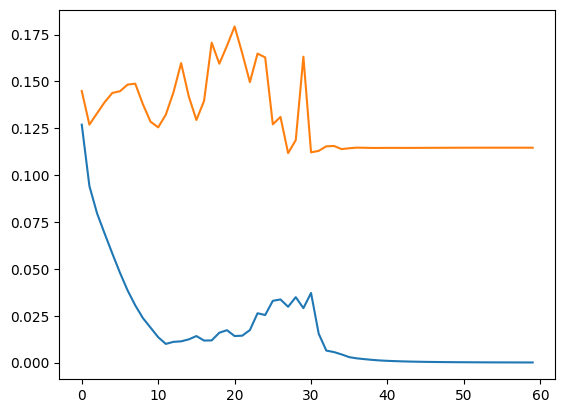

In [15]:

sns.lineplot(train_losses_first)
sns.lineplot(val_losses_first)

<Axes: >

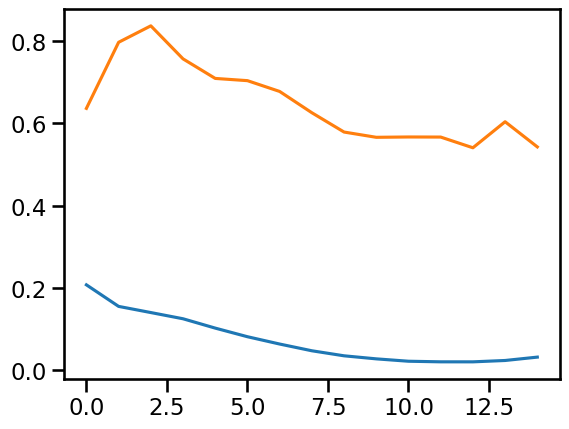

In [23]:

sns.lineplot(train_losses_second)
sns.lineplot(val_losses_second)

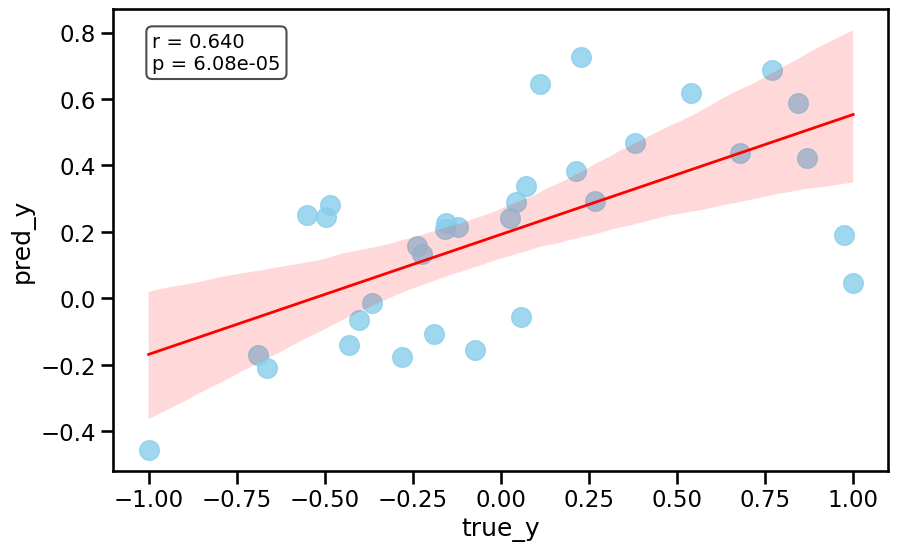

In [31]:
plots.linear_corr_plot(y_val_list,pred_y_list,'true_y','pred_y')

<Axes: >

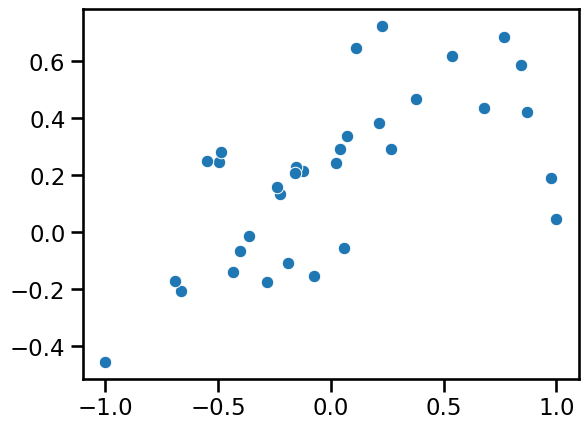

In [32]:
sns.scatterplot(x=y_val_list,y=pred_y_list)

In [ ]:
sns.lineplot(test_loss_list)

In [ ]:
sns.kdeplot(test_loss_list)

In [34]:
eqx.tree_serialise_leaves('../params/model_inference_second_training_set.eqx',inference_model)

### train on three way mmpbsa dataset

In [ ]:
# generating keys
model_key, call_key = jr.split(jrandom.PRNGKey(0), 2)

# initializing models
torch_model, _ = esm.pretrained.esm2_t30_150M_UR50D()
model_esm2 = esm2quinox.from_torch(torch_model)
model_aff, model_state = eqx.nn.make_with_state(stripped_PREDICTOR)(
    model=model_esm2, key=model_key
)

# initializing optimizer
optim = optax.adam(learning_rate=0.001)
opt_state = optim.init(eqx.filter(model_aff, eqx.is_inexact_array))

In [ ]:
best_model_first, model_state_first, train_losses_first, val_losses_first = train_model_validation(
    training_DataLoader=mmpbsa_train_data_loader_three_split,
    validation_Dataloader=mmpbsa_validation_data_loader_three_split,
    max_epochs=10,
    model_aff=model_aff,
    model_state=model_state,
    opt_state=opt_state,
    optim=optim,
    key=call_key,
)

### train easy model with both dataset

In [12]:
# generating keys
model_key, call_key = jr.split(jrandom.PRNGKey(0), 2)

# initializing models
torch_model, _ = esm.pretrained.esm2_t30_150M_UR50D()
model_esm2 = esm2quinox.from_torch(torch_model)
model_aff, model_state = eqx.nn.make_with_state(stripped_PREDICTOR)(
    model=model_esm2, key=model_key
)

# initializing optimizer
optim = optax.adam(learning_rate=0.001)
opt_state = optim.init(eqx.filter(model_aff, eqx.is_inexact_array))

In [13]:
best_model_first, model_state_first, train_losses_first, val_losses_first = train_model_validation(
    training_DataLoader=train_loader,
    validation_Dataloader=validation_loader,
    max_epochs=60,
    model_aff=model_aff,
    model_state=model_state,
    opt_state=opt_state,
    optim=optim,
    key=call_key,
)

Epochs:   0%|          | 0/60 [00:00<?, ?it/s]
















Epochs:   2%|▏         | 1/60 [00:58<57:08, 58.11s/it]

[Epoch 1] Train Loss: 0.126963, Val Loss: 0.001340
	(New best model saved.)
















Epochs:   3%|▎         | 2/60 [01:10<30:16, 31.32s/it]

[Epoch 2] Train Loss: 0.094207, Val Loss: 0.006479
	(New best model saved.)


...















Epochs:  97%|█████████▋| 58/60 [12:56<00:25, 12.61s/it]

[Epoch 58] Train Loss: 0.000086, Val Loss: 0.000210
















Epochs:  98%|█████████▊| 59/60 [13:09<00:12, 12.60s/it]

[Epoch 59] Train Loss: 0.000077, Val Loss: 0.000207


[Epoch 60] Train Loss: 0.000070, Val Loss: 0.000204
Training complete.


In [22]:
# initializing optimizer
optim = optax.adam(learning_rate=0.001)
opt_state = optim.init(eqx.filter(best_model_first, eqx.is_inexact_array))

best_model, model_state, train_losses_second, val_losses_second = train_model_validation(
    training_DataLoader=mmpbsa_train_data_loader_three_split,
    validation_Dataloader=mmpbsa_validation_data_loader_three_split,
    max_epochs=15,
    model_aff=best_model_first,
    model_state=model_state_first,
    opt_state=opt_state,
    optim=optim,
    key=call_key,
)

Epochs:   0%|          | 0/15 [00:00<?, ?it/s]

Epochs:   7%|▋         | 1/15 [00:19<04:35, 19.71s/it]

[Epoch 1] Train Loss: 0.207681, Val Loss: 0.380491
	(New best model saved.)




Epochs:  13%|█▎        | 2/15 [00:20<01:49,  8.40s/it]

[Epoch 2] Train Loss: 0.155383, Val Loss: 0.078850




Epochs:  20%|██        | 3/15 [00:20<00:57,  4.78s/it]

...



Epochs:  87%|████████▋ | 13/15 [00:25<00:01,  1.81it/s]

[Epoch 13] Train Loss: 0.020871, Val Loss: 0.178561
	(New best model saved.)




Epochs:  93%|█████████▎| 14/15 [00:25<00:00,  1.89it/s]

[Epoch 14] Train Loss: 0.024161, Val Loss: 0.129566


[Epoch 15] Train Loss: 0.032330, Val Loss: 0.142119
Training complete.


In [ ]:
# initializing optimizer
optim = optax.adam(learning_rate=0.001)
opt_state = optim.init(eqx.filter(best_model_first, eqx.is_inexact_array))

best_model, model_state, train_losses_second, val_losses_second = train_model_validation(
    training_DataLoader=mmpbsa_train_data_loader,
    validation_Dataloader=mmpbsa_validation_data_loader,
    max_epochs=5,
    model_aff=best_model_first,
    model_state=model_state_first,
    opt_state=opt_state,
    optim=optim,
    key=call_key,
)

### training real with additional layer

In [ ]:
# generating keys
model_key, call_key = jr.split(jrandom.PRNGKey(0), 2)

# initializing models
torch_model, _ = esm.pretrained.esm2_t30_150M_UR50D()
model_esm2 = esm2quinox.from_torch(torch_model)
model_aff, model_state = eqx.nn.make_with_state(fine_tune_PREDICTOR)(
    model=model_esm2, key=model_key
)

# initializing optimizer
optim = optax.adam(learning_rate=0.001)
opt_state = optim.init(eqx.filter(model_aff, eqx.is_inexact_array))

In [ ]:
best_model_first, model_state_first, train_losses_first, val_losses_first = train_model_fine_tuning(
    training_DataLoader=train_loader,
    validation_Dataloader=validation_loader,
    max_epochs=3,
    model_aff=model_aff,
    model_state=model_state,
    opt_state=opt_state,
    optim=optim,
    key=call_key,
)

In [ ]:
# initializing optimizer
optim = optax.adam(learning_rate=0.001)
opt_state = optim.init(eqx.filter(best_model_first, eqx.is_inexact_array))

best_model, model_state, train_losses_second, val_losses_second = train_model_validation(
    training_DataLoader=mmpbsa_train_data_loader,
    validation_Dataloader=mmpbsa_validation_data_loader,
    max_epochs=3,
    model_aff=best_model_first,
    model_state=model_state_first,
    opt_state=opt_state,
    optim=optim,
    key=call_key,
)